In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv("churn_cleaned.csv")

In [7]:
df.shape

(667, 20)

In [ ]:
%pip install matplotlib seaborn

In [9]:
type(df)

pandas.DataFrame

# Codveda Internship — Level 1 Task 2: Exploratory Data Analysis

## Objective
Perform exploratory data analysis on the customer churn dataset to identify
patterns, trends, relationships, and summary statistics.

The analysis includes:
- Mean, median, mode, and standard deviation
- Data distributions using histograms
- Outlier detection using boxplots
- Relationships between variables using scatter plots
- Correlation analysis between numerical features

## Dataset Overview

The dataset contains 667 customer records and 20 variables related to
customer usage, plans, charges, customer service interactions, and churn.

The target variable is `Churn`, which indicates whether a customer
left the service.

In [10]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,8.407796,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718
std,40.819480,41.783305,13.994480,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357
min,1.000000,408.000000,0.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,0.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000
50%,102.000000,415.000000,0.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000
75%,128.000000,415.000000,20.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000
max,232.000000,510.000000,51.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000


In [11]:
df["Churn"].value_counts()

Churn
False    572
True      95
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
False    85.757121
True     14.242879
Name: proportion, dtype: float64

In [13]:
df['International plan'].value_counts()

International plan
No     614
Yes     53
Name: count, dtype: int64

In [14]:
df['Voice mail plan'].value_counts()

Voice mail plan
No     478
Yes    189
Name: count, dtype: int64

In [15]:
df['State'].value_counts().head(10)

State
AZ    19
WA    18
NM    18
KS    18
NJ    18
WV    18
ND    18
IN    17
ID    17
WI    17
Name: count, dtype: int64

In [16]:
pd.crosstab(df["International plan"], df["Churn"])

Churn,False,True
International plan,,
No,538,76
Yes,34,19


In [17]:
pd.crosstab(df["Voice mail plan"], df["Churn"])

Churn,False,True
Voice mail plan,,
No,398,80
Yes,174,15


In [18]:
df.groupby("Churn")[[
    "Account length",
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes",
    "Customer service calls"
]].mean()

,Account length,Total day minutes,Total eve minutes,Total night minutes,Total intl minutes,Customer service calls
Churn,,,,,,
False,102.636364,175.460140,199.799650,198.815385,10.242657,1.437063
True,104.073684,213.991579,224.764211,204.923158,10.212632,2.326316


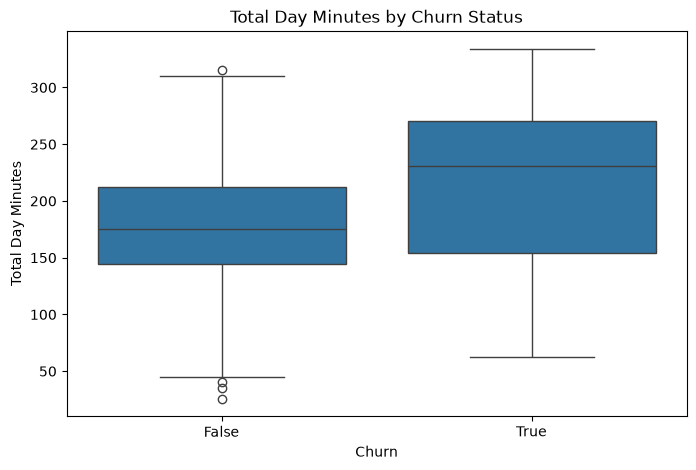

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="Total day minutes")
plt.title("Total Day Minutes by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Day Minutes")
plt.show()

In [20]:
df.mean(numeric_only=True)

Account length            102.841079
Area code                 436.157421
Number vmail messages       8.407796
Total day minutes         180.948126
Total day calls           100.937031
Total day charge           30.761769
Total eve minutes         203.355322
Total eve calls           100.476762
Total eve charge           17.285262
Total night minutes       199.685307
Total night calls         100.113943
Total night charge          8.985907
Total intl minutes         10.238381
Total intl calls            4.527736
Total intl charge           2.764948
Customer service calls      1.563718
Churn                       0.142429
dtype: float64

In [21]:
df.median(numeric_only=True).iloc[0]

np.float64(102.0)

In [22]:
df.std(numeric_only=True)

Account length            40.819480
Area code                 41.783305
Number vmail messages     13.994480
Total day minutes         55.508628
Total day calls           20.396790
Total day charge           9.436463
Total eve minutes         49.719268
Total eve calls           18.948262
Total eve charge           4.226160
Total night minutes       49.759931
Total night calls         20.172505
Total night charge         2.239429
Total intl minutes         2.807850
Total intl calls           2.482442
Total intl charge          0.758167
Customer service calls     1.333357
Churn                      0.349752
dtype: float64

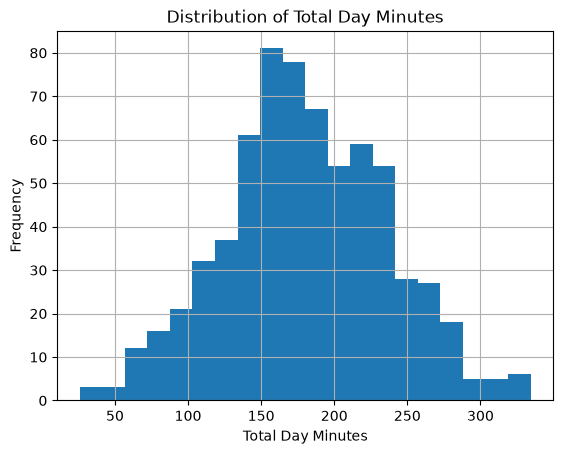

In [23]:
import matplotlib.pyplot as plt
df["Total day minutes"].hist(bins=20)
plt.title("Distribution of Total Day Minutes")
plt.xlabel("Total Day Minutes")
plt.ylabel("Frequency")
plt.show()

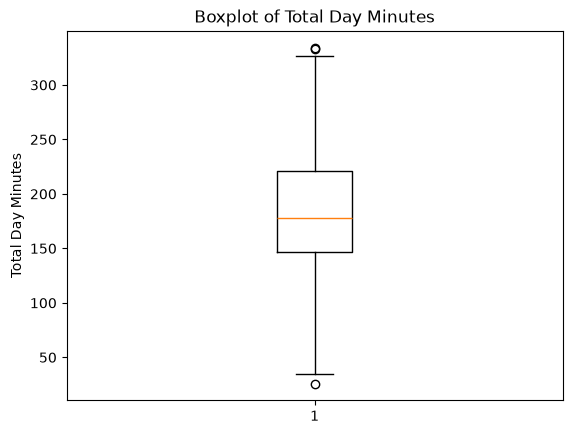

In [24]:
plt.boxplot(df["Total day minutes"])
plt.title("Boxplot of Total Day Minutes")
plt.ylabel("Total Day Minutes")
plt.show()

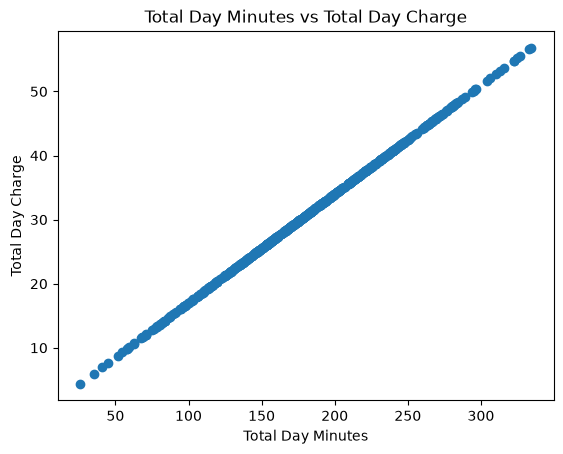

In [25]:
plt.scatter(df["Total day minutes"], df["Total day charge"])
plt.title("Total Day Minutes vs Total Day Charge")
plt.xlabel("Total Day Minutes")
plt.ylabel("Total Day Charge")
plt.show()

In [26]:
correlation = df.corr(numeric_only=True)
correlation

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
Account length,1.000000,-0.026327,-0.011993,0.017833,0.035703,0.017839,0.027043,0.021237,0.027051,-0.007527,0.027228,-0.007528,0.002362,0.031279,0.002456,-0.027677,0.012315
Area code,-0.026327,1.000000,-0.006907,0.051507,-0.008972,0.051492,0.017160,0.017783,0.017182,-0.016832,0.036421,-0.016818,-0.037980,-0.010530,-0.038044,0.000103,0.027129
Number vmail messages,-0.011993,-0.006907,1.000000,-0.069172,-0.009952,-0.069187,0.040865,-0.051951,0.040876,0.039751,0.003367,0.039680,0.029949,-0.036847,0.029999,0.007859,-0.102381
Total day minutes,0.017833,0.051507,-0.069172,1.000000,-0.032306,1.000000,0.017987,0.043219,0.017945,-0.031600,0.052761,-0.031603,-0.006725,0.016597,-0.006841,0.029291,0.242781
Total day calls,0.035703,-0.008972,-0.009952,-0.032306,1.000000,-0.032319,-0.004688,0.005851,-0.004664,0.079536,-0.030074,0.079529,-0.015319,-0.005155,-0.015201,-0.045953,0.019360
Total day charge,0.017839,0.051492,-0.069187,1.000000,-0.032319,1.000000,0.017983,0.043231,0.017941,-0.031613,0.052748,-0.031616,-0.006720,0.016582,-0.006836,0.029290,0.242777
Total eve minutes,0.027043,0.017160,0.040865,0.017987,-0.004688,0.017983,1.000000,-0.029077,1.000000,-0.007705,0.001938,-0.007603,-0.027855,0.002929,-0.027887,-0.012213,0.175614
Total eve calls,0.021237,0.017783,-0.051951,0.043219,0.005851,0.043231,-0.029077,1.000000,-0.029089,-0.009856,0.036068,-0.009833,-0.001050,0.074829,-0.001152,0.008126,0.055669
Total eve charge,0.027051,0.017182,0.040876,0.017945,-0.004664,0.017941,1.000000,-0.029089,1.000000,-0.007691,0.001939,-0.007589,-0.027863,0.002894,-0.027895,-0.012212,0.175616
Total night minutes,-0.007527,-0.016832,0.039751,-0.031600,0.079536,-0.031613,-0.007705,-0.009856,-0.007691,1.000000,0.005209,0.999999,-0.041969,-0.057212,-0.042221,-0.067602,0.042930


In [27]:
df.mean(numeric_only=True)

Account length            102.841079
Area code                 436.157421
Number vmail messages       8.407796
Total day minutes         180.948126
Total day calls           100.937031
Total day charge           30.761769
Total eve minutes         203.355322
Total eve calls           100.476762
Total eve charge           17.285262
Total night minutes       199.685307
Total night calls         100.113943
Total night charge          8.985907
Total intl minutes         10.238381
Total intl calls            4.527736
Total intl charge           2.764948
Customer service calls      1.563718
Churn                       0.142429
dtype: float64

In [28]:
df.median(numeric_only=True)

Account length            102.00
Area code                 415.00
Number vmail messages       0.00
Total day minutes         178.30
Total day calls           101.00
Total day charge           30.31
Total eve minutes         203.70
Total eve calls           101.00
Total eve charge           17.31
Total night minutes       201.60
Total night calls         100.00
Total night charge          9.07
Total intl minutes         10.50
Total intl calls            4.00
Total intl charge           2.84
Customer service calls      1.00
Churn                       0.00
dtype: float64

In [29]:
df.mode(numeric_only=True).iloc[0]

Account length             95.0
Area code                 415.0
Number vmail messages       0.0
Total day minutes         153.5
Total day calls           102.0
Total day charge           26.1
Total eve minutes         180.5
Total eve calls           101.0
Total eve charge          18.33
Total night minutes       188.2
Total night calls          86.0
Total night charge         9.45
Total intl minutes         11.3
Total intl calls            3.0
Total intl charge          3.05
Customer service calls      1.0
Churn                     False
Name: 0, dtype: object

In [30]:
df.std(numeric_only=True)

Account length            40.819480
Area code                 41.783305
Number vmail messages     13.994480
Total day minutes         55.508628
Total day calls           20.396790
Total day charge           9.436463
Total eve minutes         49.719268
Total eve calls           18.948262
Total eve charge           4.226160
Total night minutes       49.759931
Total night calls         20.172505
Total night charge         2.239429
Total intl minutes         2.807850
Total intl calls           2.482442
Total intl charge          0.758167
Customer service calls     1.333357
Churn                      0.349752
dtype: float64

### Summary Statistics Findings

The descriptive statistics provide an overview of the central tendency
and variation of the numerical variables. Account length is relatively
similar across customers, while usage variables such as daytime and
evening minutes show greater variation.

Churned customers also showed higher average daytime and evening usage
and more customer service calls than customers who did not churn.

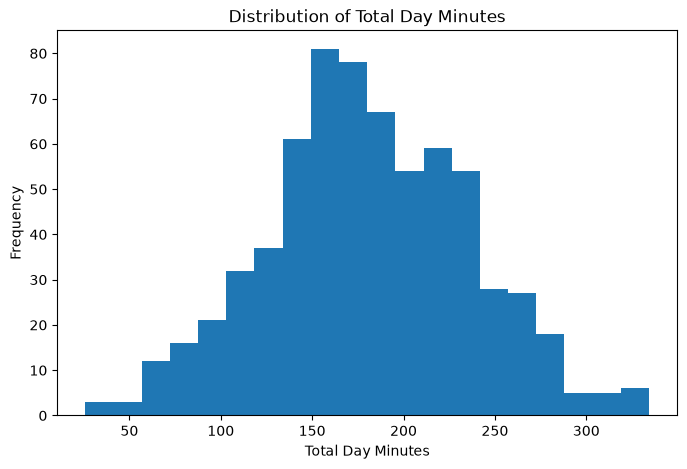

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["Total day minutes"], bins=20)

plt.title("Distribution of Total Day Minutes")
plt.xlabel("Total Day Minutes")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The distribution shows how total daytime usage varies across customers.
Most observations are concentrated around the central range, with some
customers recording considerably higher usage.

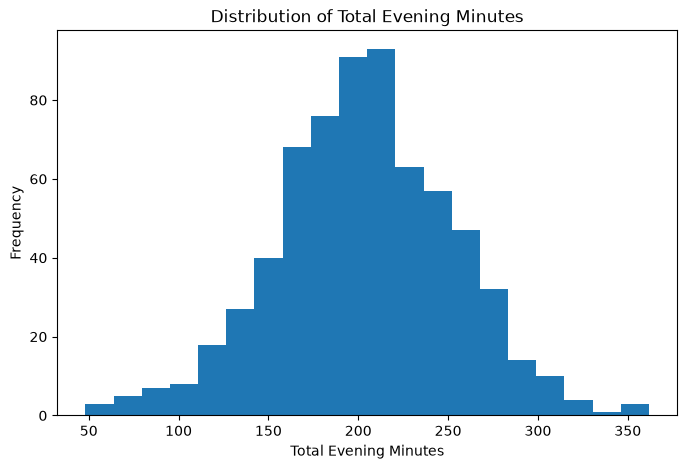

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df["Total eve minutes"], bins=20)

plt.title("Distribution of Total Evening Minutes")
plt.xlabel("Total Evening Minutes")
plt.ylabel("Frequency")

plt.show()

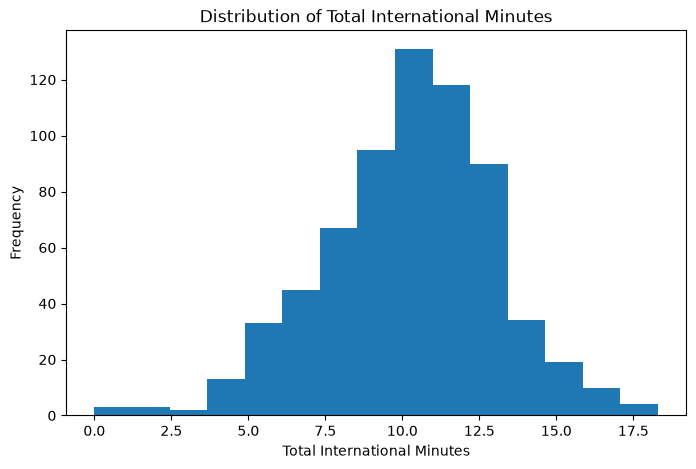

In [33]:
plt.figure(figsize=(8,5))

plt.hist(df["Total intl minutes"], bins=15)

plt.title("Distribution of Total International Minutes")
plt.xlabel("Total International Minutes")
plt.ylabel("Frequency")

plt.show()

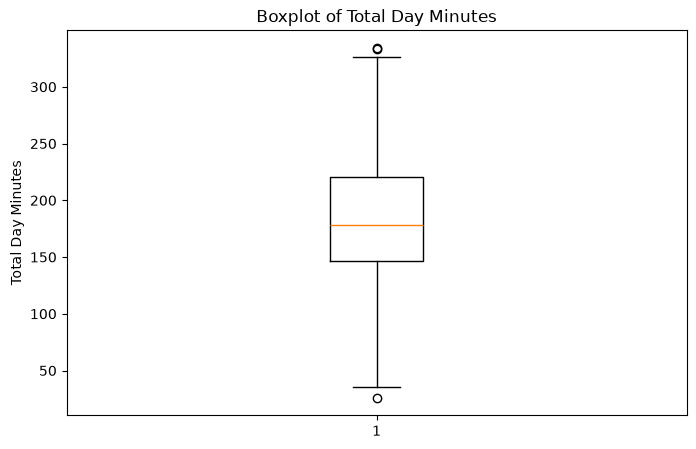

In [34]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Total day minutes"])

plt.title("Boxplot of Total Day Minutes")
plt.ylabel("Total Day Minutes")

plt.show()

### Interpretation

The boxplot helps identify the spread of daytime usage and potential
outliers. The presence of observations beyond the main distribution
indicates customers with unusually high daytime usage.

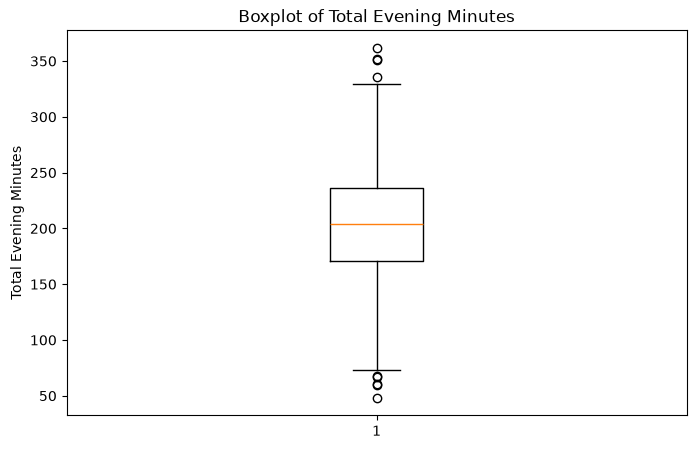

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Total eve minutes"])

plt.title("Boxplot of Total Evening Minutes")
plt.ylabel("Total Evening Minutes")

plt.show()

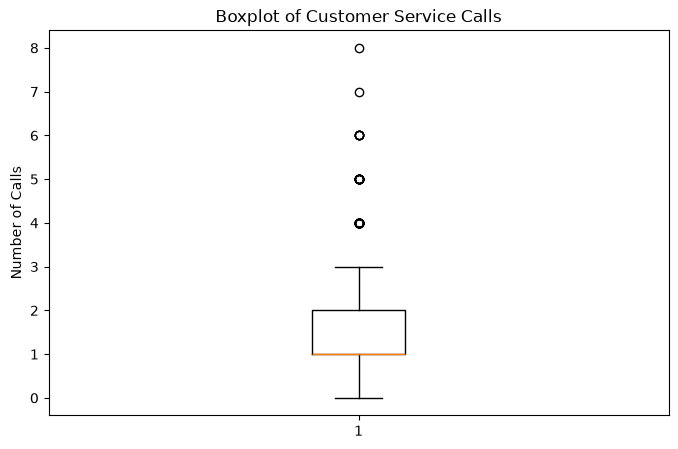

In [36]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Customer service calls"])

plt.title("Boxplot of Customer Service Calls")
plt.ylabel("Number of Calls")

plt.show()

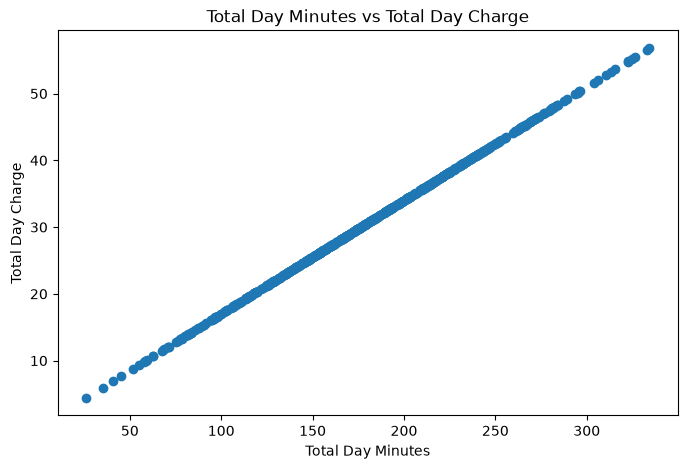

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(df["Total day minutes"], df["Total day charge"])

plt.title("Total Day Minutes vs Total Day Charge")
plt.xlabel("Total Day Minutes")
plt.ylabel("Total Day Charge")

plt.show()

### Interpretation

The scatter plot shows a strong positive relationship between total
daytime minutes and total daytime charges. This is expected because
daytime charges are directly related to daytime usage.

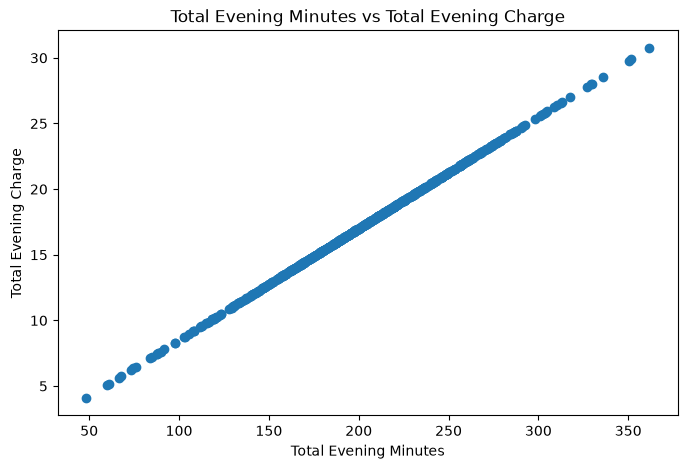

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(df["Total eve minutes"], df["Total eve charge"])

plt.title("Total Evening Minutes vs Total Evening Charge")
plt.xlabel("Total Evening Minutes")
plt.ylabel("Total Evening Charge")

plt.show()

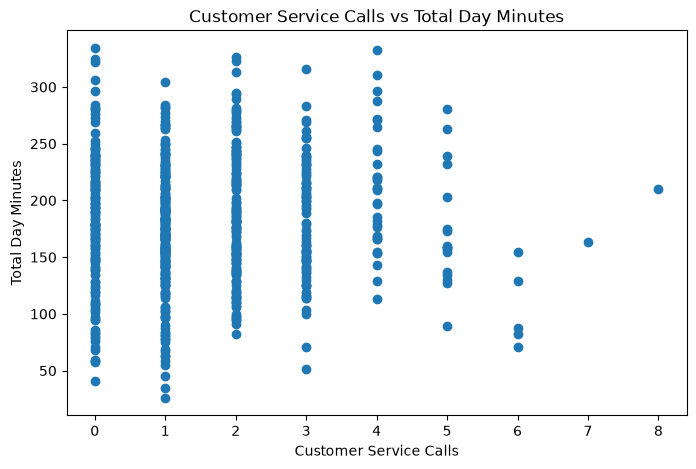

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(df["Customer service calls"], df["Total day minutes"])

plt.title("Customer Service Calls vs Total Day Minutes")
plt.xlabel("Customer Service Calls")
plt.ylabel("Total Day Minutes")

plt.show()

In [40]:
correlation = df.corr(numeric_only=True)
correlation

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
Account length,1.000000,-0.026327,-0.011993,0.017833,0.035703,0.017839,0.027043,0.021237,0.027051,-0.007527,0.027228,-0.007528,0.002362,0.031279,0.002456,-0.027677,0.012315
Area code,-0.026327,1.000000,-0.006907,0.051507,-0.008972,0.051492,0.017160,0.017783,0.017182,-0.016832,0.036421,-0.016818,-0.037980,-0.010530,-0.038044,0.000103,0.027129
Number vmail messages,-0.011993,-0.006907,1.000000,-0.069172,-0.009952,-0.069187,0.040865,-0.051951,0.040876,0.039751,0.003367,0.039680,0.029949,-0.036847,0.029999,0.007859,-0.102381
Total day minutes,0.017833,0.051507,-0.069172,1.000000,-0.032306,1.000000,0.017987,0.043219,0.017945,-0.031600,0.052761,-0.031603,-0.006725,0.016597,-0.006841,0.029291,0.242781
Total day calls,0.035703,-0.008972,-0.009952,-0.032306,1.000000,-0.032319,-0.004688,0.005851,-0.004664,0.079536,-0.030074,0.079529,-0.015319,-0.005155,-0.015201,-0.045953,0.019360
Total day charge,0.017839,0.051492,-0.069187,1.000000,-0.032319,1.000000,0.017983,0.043231,0.017941,-0.031613,0.052748,-0.031616,-0.006720,0.016582,-0.006836,0.029290,0.242777
Total eve minutes,0.027043,0.017160,0.040865,0.017987,-0.004688,0.017983,1.000000,-0.029077,1.000000,-0.007705,0.001938,-0.007603,-0.027855,0.002929,-0.027887,-0.012213,0.175614
Total eve calls,0.021237,0.017783,-0.051951,0.043219,0.005851,0.043231,-0.029077,1.000000,-0.029089,-0.009856,0.036068,-0.009833,-0.001050,0.074829,-0.001152,0.008126,0.055669
Total eve charge,0.027051,0.017182,0.040876,0.017945,-0.004664,0.017941,1.000000,-0.029089,1.000000,-0.007691,0.001939,-0.007589,-0.027863,0.002894,-0.027895,-0.012212,0.175616
Total night minutes,-0.007527,-0.016832,0.039751,-0.031600,0.079536,-0.031613,-0.007705,-0.009856,-0.007691,1.000000,0.005209,0.999999,-0.041969,-0.057212,-0.042221,-0.067602,0.042930


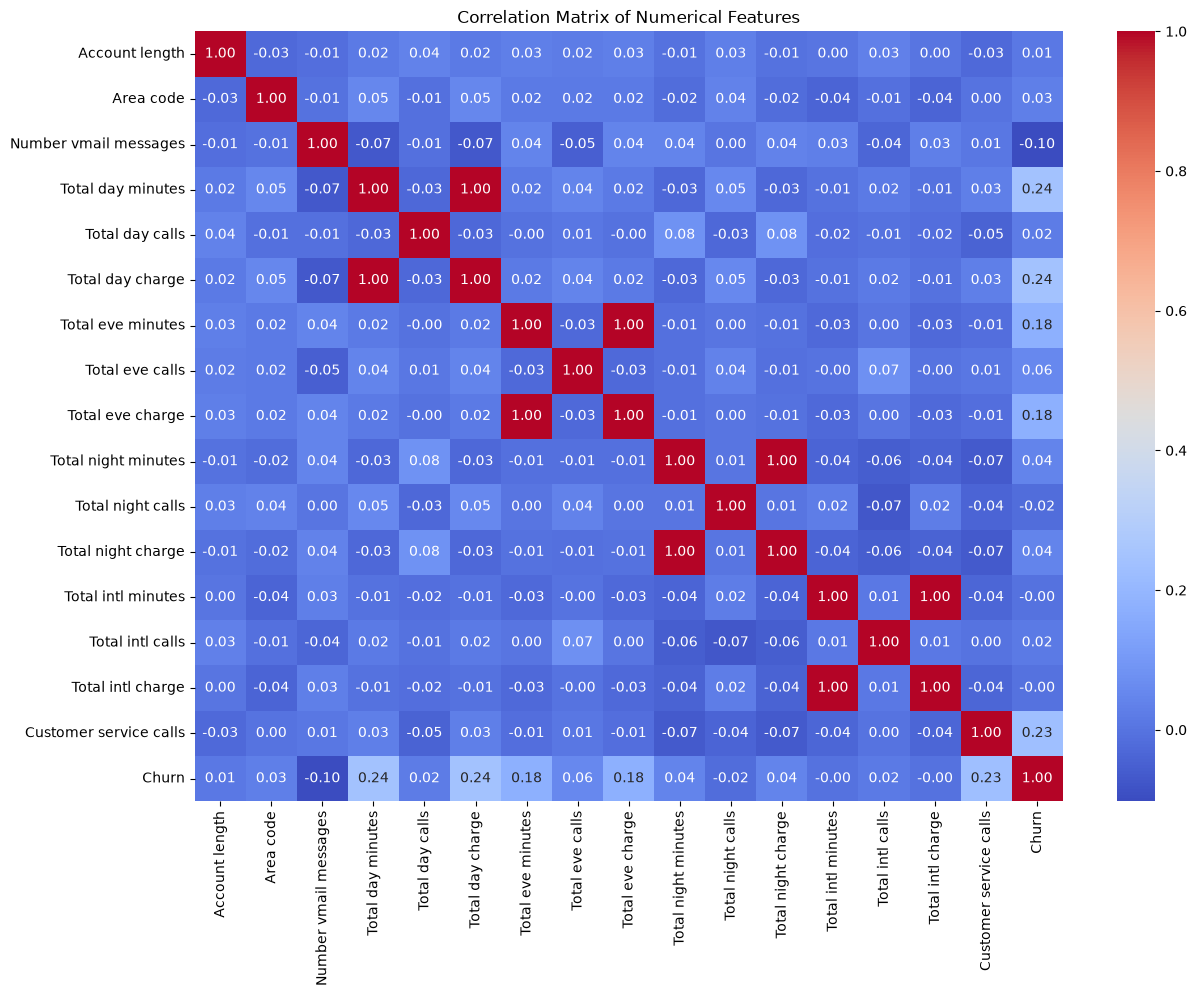

In [41]:
plt.figure(figsize=(14,10))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [42]:
corr_pairs = correlation.unstack()
corr_pairs = corr_pairs[corr_pairs != 1]
corr_pairs.abs().sort_values(ascending=False).head(15)

Total day minutes       Total day charge          1.000000
Total day charge        Total day minutes         1.000000
Total eve charge        Total eve minutes         1.000000
Total eve minutes       Total eve charge          1.000000
Total night minutes     Total night charge        0.999999
Total night charge      Total night minutes       0.999999
Total intl minutes      Total intl charge         0.999993
Total intl charge       Total intl minutes        0.999993
Churn                   Total day minutes         0.242781
Total day minutes       Churn                     0.242781
Churn                   Total day charge          0.242777
Total day charge        Churn                     0.242777
Customer service calls  Churn                     0.233259
Churn                   Customer service calls    0.233259
                        Total eve charge          0.175616
dtype: float64

## Correlation Analysis

The correlation matrix was used to examine relationships between
numerical variables.

The strongest meaningful positive associations with churn were:

- Total day minutes: 0.243
- Customer service calls: 0.233

The very strong correlations between usage minutes and their
corresponding charges are expected because the charges are directly
related to usage.

## Conclusion

The exploratory analysis identified several patterns associated with
customer churn.

Approximately 14.24% of customers in the dataset churned. Customers
with an international plan had a higher observed churn rate than those
without one, while customers without a voice mail plan also showed a
higher churn rate.

Churned customers had higher average daytime and evening usage and
made more customer service calls than customers who remained with the
service. Correlation analysis also showed positive associations between
churn, total day minutes, and customer service calls.

These findings provide useful indicators for further analysis and can
be explored more deeply using predictive modelling.